# ***Q1***

In [4]:
from google.colab import files

uploaded = files.upload()

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset.csv


In [5]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (299, 13)


In [6]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



***Q3***

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.dtypes #DATA TYPES
df.isnull().sum()  #MISSIBG VALUES
df.info() #COMPLETE INFO

Number of rows: 299
Number of columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10

***Q4. Visualize Missing Values***

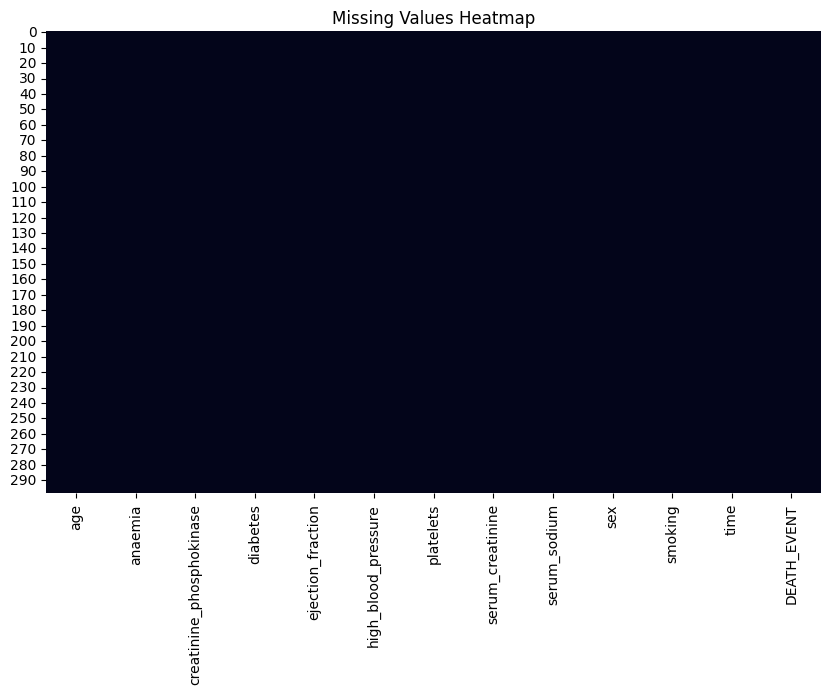

In [10]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [11]:
# CREATING MISSING VALUES
df.loc[0, "serum_creatinine"] = np.nan
df.loc[5, "age"] = np.nan
df.loc[10, "smoking"] = np.nan
df.loc[15, "ejection_fraction"] = np.nan

print("Missing values created for demonstration:")
print(df.isnull().sum())

Missing values created for demonstration:
age                         1
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           1
high_blood_pressure         0
platelets                   0
serum_creatinine            1
serum_sodium                0
sex                         0
smoking                     1
time                        0
DEATH_EVENT                 0
dtype: int64


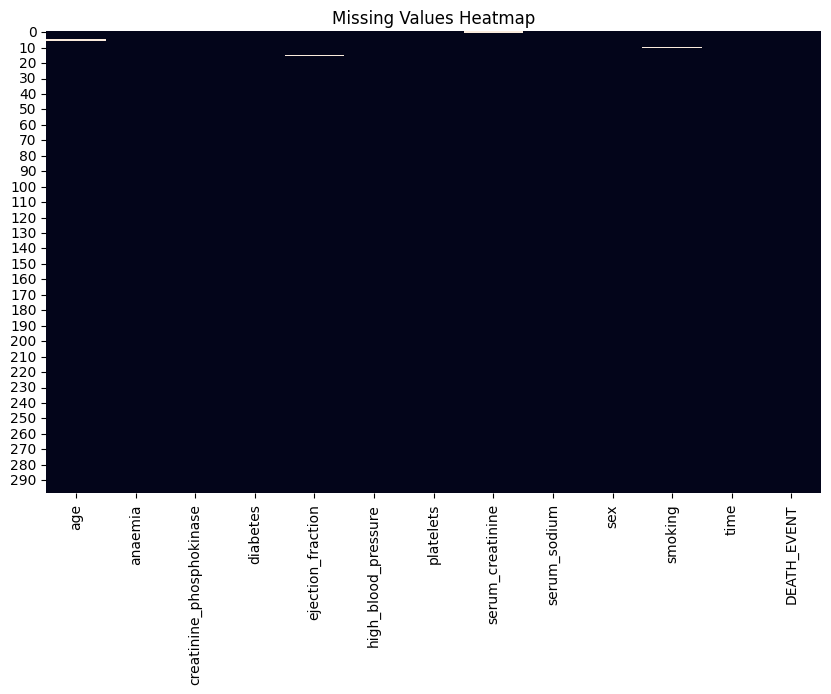

In [13]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

***Q5. Plot Distributions***

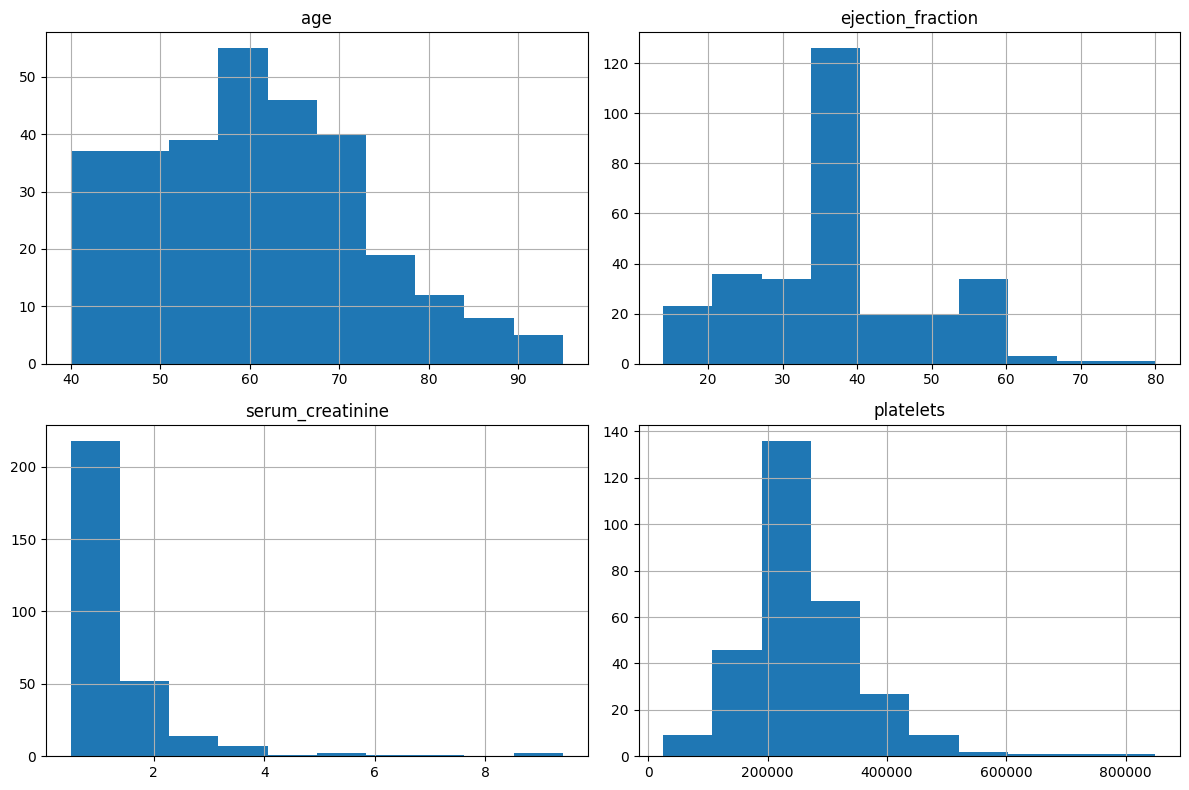

In [14]:
# HISTOGRAM
df[["age", "ejection_fraction", "serum_creatinine", "platelets"]].hist(
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

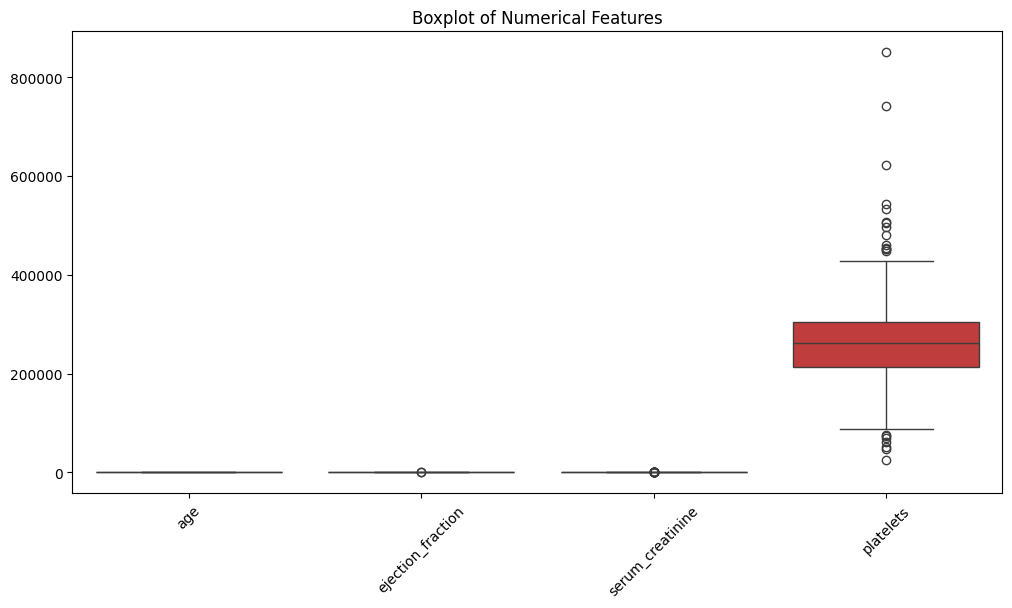

In [16]:
# BOXPLOT
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[["age", "ejection_fraction", "serum_creatinine", "platelets"]])

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

***Q6. Impute Missing Values***

In [17]:
# Fill numerical missing values with median

df["age"] = df["age"].fillna(df["age"].median())

df["ejection_fraction"] = df["ejection_fraction"].fillna(
    df["ejection_fraction"].median()
)

df["serum_creatinine"] = df["serum_creatinine"].fillna(
    df["serum_creatinine"].median()
)

In [18]:
# Fill categorical missing value with mode

df["smoking"] = df["smoking"].fillna(df["smoking"].mode()[0])

In [19]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


***Q7. Remove Outliers***

In [20]:
numerical_columns = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]

print("Outliers removed.")
print("Remaining rows:", len(df))

Outliers removed.
Remaining rows: 251


***Q8. Correct Inconsistencies***

In [21]:
print("Negative age values:")
print(df[df["age"] < 0])

print("Invalid ejection fraction:")
print(df[df["ejection_fraction"] <= 0])

print("Invalid serum creatinine:")
print(df[df["serum_creatinine"] <= 0])

Negative age values:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []
Invalid ejection fraction:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []
Invalid serum creatinine:
Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [22]:
# Remove invalid age values
df = df[df["age"] > 0]

# Remove invalid ejection fraction values
df = df[df["ejection_fraction"] > 0]

# Remove invalid serum creatinine values
df = df[df["serum_creatinine"] > 0]

print("Invalid entries removed.")

Invalid entries removed.


***Q9. Feature Engineering***

In [23]:
def age_group(age):
    if age < 40:
        return "<40"
    elif age <= 60:
        return "40-60"
    else:
        return ">60"

df["age_group"] = df["age"].apply(age_group)

df[["age", "age_group"]].head()

,age,age_group
0,75.0,>60
1,55.0,40-60
2,65.0,>60
3,50.0,40-60
5,60.0,40-60


In [24]:
df["risk_score"] = df["ejection_fraction"] * df["serum_creatinine"]

# Normalize risk score between 0 and 1
df["risk_score"] = (
    (df["risk_score"] - df["risk_score"].min()) /
    (df["risk_score"].max() - df["risk_score"].min())
)

df[["ejection_fraction", "serum_creatinine", "risk_score"]].head()

,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.1,0.115756
1,38.0,1.1,0.327974
2,20.0,1.3,0.158628
3,20.0,1.9,0.287245
5,40.0,2.1,0.780279


***Q10. Encode Categorical Variables***

In [25]:
# ONE HOT ENCODING
df = pd.get_dummies(
    df,
    columns=["sex", "smoking", "age_group"],
    drop_first=True
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_1,smoking_1.0,age_group_>60
0,75.0,0,582,0,20.0,1,265000.00,1.1,130,4,1,0.115756,True,False,True
1,55.0,0,7861,0,38.0,0,263358.03,1.1,136,6,1,0.327974,True,False,False
2,65.0,0,146,0,20.0,0,162000.00,1.3,129,7,1,0.158628,True,True,True
3,50.0,1,111,0,20.0,0,210000.00,1.9,137,7,1,0.287245,True,False,False
5,60.0,1,47,0,40.0,1,204000.00,2.1,132,8,1,0.780279,True,True,False


***Q11. Normalize Features***

In [26]:
from sklearn.preprocessing import MinMaxScaler

In [27]:
scaler = MinMaxScaler()

columns_to_scale = [
    "age",
    "platelets",
    "ejection_fraction",
    "serum_creatinine"
]

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df[columns_to_scale].head()

,age,platelets,ejection_fraction,serum_creatinine
0,0.636364,0.523529,0.117647,0.375
1,0.272727,0.518700,0.470588,0.375
2,0.454545,0.220588,0.117647,0.500
3,0.181818,0.361765,0.117647,0.875
5,0.363636,0.344118,0.509804,1.000


***Q12. Compute Summary Statistics***

In [29]:
original_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [30]:
# Statistics Before Cleaning
before_stats = original_df[
    ["age", "ejection_fraction", "serum_creatinine", "platelets"]
].agg(["mean", "median", "std"])

before_stats

,age,ejection_fraction,serum_creatinine,platelets
mean,60.833893,38.083612,1.39388,263358.029264
median,60.000000,38.000000,1.10000,262000.000000
std,11.894809,11.834841,1.03451,97804.236869


In [31]:
#After Cleaning Statistics
after_stats = df[
    ["age", "ejection_fraction", "serum_creatinine", "platelets"]
].agg(["mean", "median", "std"])

after_stats

,age,ejection_fraction,serum_creatinine,platelets
mean,0.367065,0.469260,0.391833,0.495984
median,0.363636,0.470588,0.375000,0.517647
std,0.213613,0.226291,0.206967,0.200093


***Q13. Validate Cleaning***

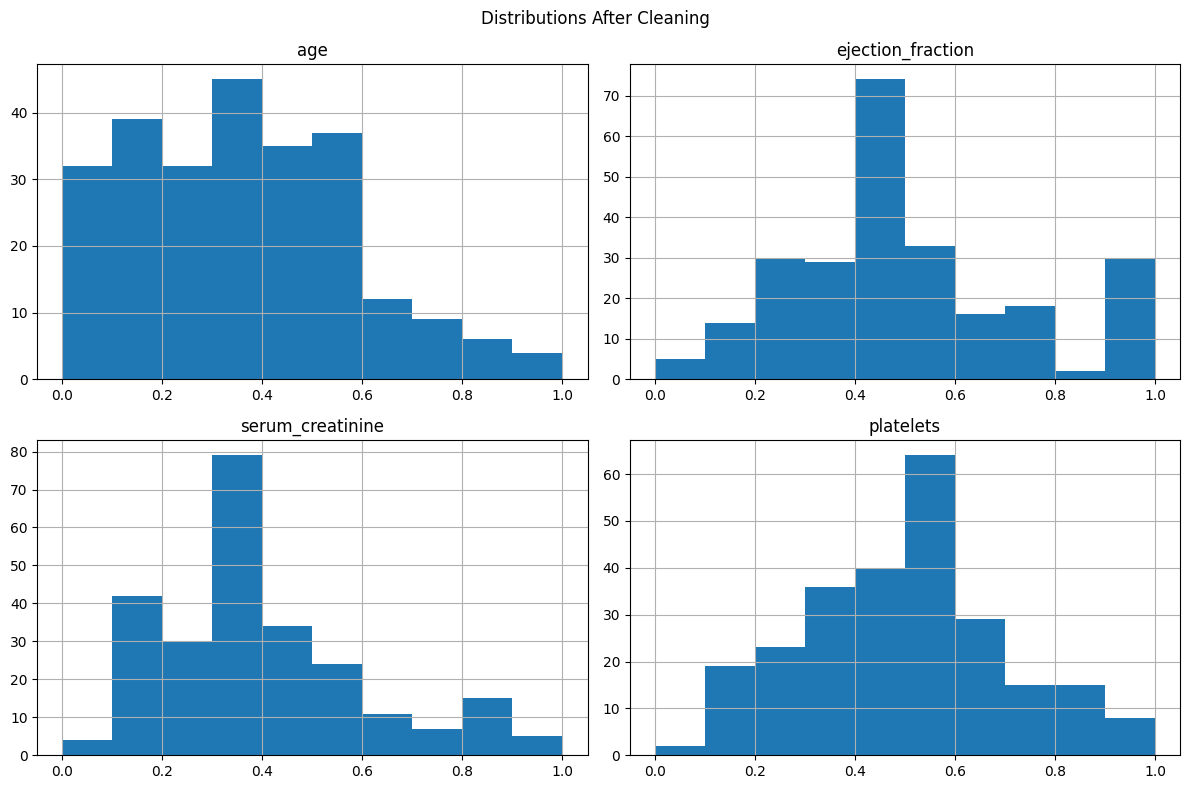

In [32]:
# CLEANED DATA HISTOGRAM
df[
    ["age", "ejection_fraction", "serum_creatinine", "platelets"]
].hist(figsize=(12, 8))

plt.suptitle("Distributions After Cleaning")

plt.tight_layout()
plt.show()

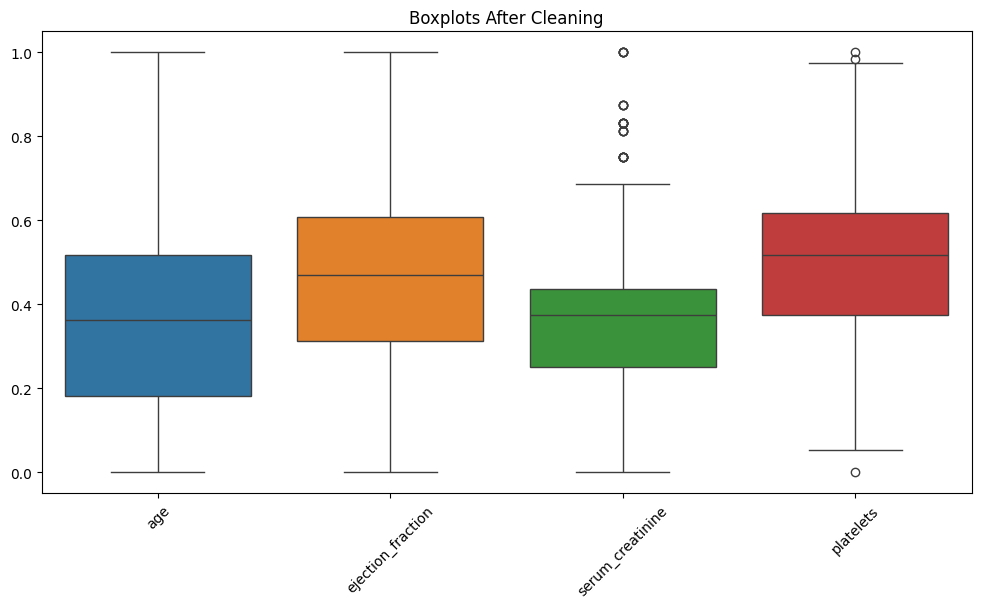

In [33]:
# CLEANED DATA BOXPLOT
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[
        ["age", "ejection_fraction", "serum_creatinine", "platelets"]
    ]
)

plt.title("Boxplots After Cleaning")
plt.xticks(rotation=45)
plt.show()

***Q14. Check Missing Values***

In [34]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
time                        0
DEATH_EVENT                 0
risk_score                  0
sex_1                       0
smoking_1.0                 0
age_group_>60               0
dtype: int64


In [35]:
# FINAL DATA SET
print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (251, 15)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_1,smoking_1.0,age_group_>60
0,0.636364,0,582,0,0.117647,1,0.523529,0.375,130,4,1,0.115756,True,False,True
1,0.272727,0,7861,0,0.470588,0,0.518700,0.375,136,6,1,0.327974,True,False,False
2,0.454545,0,146,0,0.117647,0,0.220588,0.500,129,7,1,0.158628,True,True,True
3,0.181818,1,111,0,0.117647,0,0.361765,0.875,137,7,1,0.287245,True,False,False
5,0.363636,1,47,0,0.509804,1,0.344118,1.000,132,8,1,0.780279,True,True,False
